In [4]:
#Misalkan terdapat daftar yang tidak terurut berisi N elemen,
#Kemdian kita ingin menemukan elemen tertentu dari daftar tersebut yg disebut W

listku = [1,3,5,9,4,8,2,6,0,7,1]
def oracle(output):
    pemenang=4
    if output is pemenang:
        response = 'Yeay'
    else:
        response = 'No'
    return response


In [7]:
#Berapa kali harus memanggil oracle agar menemukan pemenangnya 

for i, angka_coba in enumerate(listku):
    if oracle(angka_coba) == 'Yeay':
        print('Pemenang ditemukan pada index %i' %i)
        print('oracle dipanggil sebanyak %i kali ' %(i+1))
        break

Pemenang ditemukan pada index 4
oracle dipanggil sebanyak 5 kali 


### Menampilkan  Operator Difusi Grover ###

In [14]:
from qiskit import * 
from qiskit_aer import Aer
import matplotlib as plt
import numpy as np

### QUANTUM ###


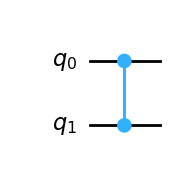

In [ ]:
#Mendefinisikan sirkuit oracle 
oracle_ni = QuantumCircuit(2,name='oracle_ni')
oracle_ni.cz(0,1)
oracle_ni.to_gate()
oracle_ni.draw('mpl')


### Memeriksa apakah oracle melakukan apa yang diinginkan ###
    Dengan menyiapkan keadaan superposisi dari semua kubit yg menerapkan gerbang Hadamard

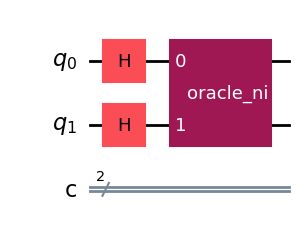

In [25]:
backend = Aer.get_backend('statevector_simulator')
grover_sirkuit = QuantumCircuit(2,2)
grover_sirkuit.h([0,1])
grover_sirkuit.append(oracle_ni, [0,1])
grover_sirkuit.draw('mpl')

In [ ]:
grover_sirkuit = grover_sirkuit.decompose() #Memecah gate kompleks/custom gate menjadi gate dasar yang dikenali simulator 
#Menjalankan pekerjaan di simulator
job = backend.run(grover_sirkuit)
result = job.result()

In [29]:
#Mengambil kembali keadaan vektornya 
sv = result.get_statevector()
np.around(sv,2)

array([ 0.5+0.j,  0.5+0.j,  0.5+0.j, -0.5+0.j])

### OPERASI DIFUSI GROVER ###
### Operator refleksi ###
Memperbesar amplitudo jawaban benar, memperkuat probabilitas state yang benar.

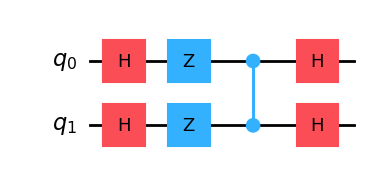

In [32]:
refleksi = QuantumCircuit(2,name='refleksi')
refleksi.h([0,1])
refleksi.z([0,1])
refleksi.cz(0,1)
refleksi.h([0,1])
refleksi.to_gate()
refleksi.draw('mpl')

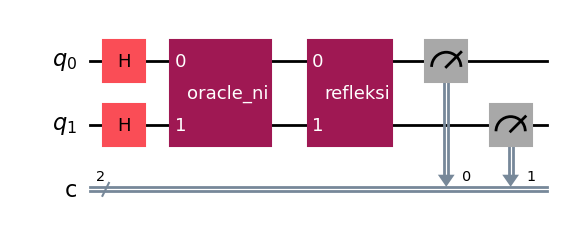

In [34]:
backend= Aer.get_backend('qasm_simulator')
grover_sirkuit = QuantumCircuit(2,2)
grover_sirkuit.h([0,1])
grover_sirkuit.append(oracle_ni, [0,1])
grover_sirkuit.append(refleksi, [0,1])
grover_sirkuit.measure([0,1] , [0,1])
grover_sirkuit.draw('mpl')

In [36]:
grover_sirkuit = grover_sirkuit.decompose() 
job = backend.run(grover_sirkuit)
result = job.result()
result.get_counts()

{'11': 1024}

Dengan menggunakan amplifikasi amplitudo kita bisa menghemat biaya dengan hanya menggunakan akar kuadrat dari N panggilan ke oracle.